# 03 — Concisão e foco (11 modelos)

Análise da **concisão** das respostas — quanto cada modelo "fala" e se a verbosidade
prejudica a qualidade percebida pelo avaliador.

Base: `analise_consolidada.xlsx` (1.650 linhas, rubric unificado com score 0/0.5/1
que combina correção e foco) + contagem de tokens via `tiktoken cl100k_base`
(fallback por palavras quando indisponível).

**Cobertura: todos os 11 modelos** (9 API + 2 chats).

In [1]:
# Setup comum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_AVALIADOR = {'gpt': '#10A37F', 'opus': '#D97757', 'humano': '#8E44AD'}
PALETA_TIPO = {'api': '#2E86AB', 'chat': '#E74C3C'}
CORES_NOTA = {0.0: '#E74C3C', 0.5: '#F39C12', 1.0: '#2ECC71'}

# Detecta a pasta data/ automaticamente — tenta vários caminhos
def find_data_dir():
    candidatos = [Path('.'), Path('data'), Path('../data'), Path('../../data'),
                  Path('./data'), Path('../../../data')]
    for p in candidatos:
        if (p / 'df_avaliacoes.xlsx').exists():
            return p.resolve()
    raise FileNotFoundError(
        'Não encontrei df_avaliacoes.xlsx. Coloque os 5 arquivos .xlsx '
        'em ./data/, ../data/, ou no mesmo diretório do notebook, ou edite '
        'a variável DATA manualmente abaixo.'
    )

DATA = find_data_dir()
INTER = DATA.parent / 'output' / 'intermediarios'
INTER.mkdir(parents=True, exist_ok=True)
print(f'DATA  = {DATA}')
print(f'INTER = {INTER}')

DATA  = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/tcc_analise
INTER = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/output/intermediarios


In [2]:
# Tokenizador
try:
    import tiktoken
    ENC = tiktoken.get_encoding('cl100k_base')
    def count_tokens(s):
        return 0 if not isinstance(s, str) or not s else len(ENC.encode(s))
    TOKENIZER = 'tiktoken/cl100k_base'
except Exception as e:
    def count_tokens(s):
        return 0 if not isinstance(s, str) or not s else int(round(len(s.split()) / 0.75))
    TOKENIZER = f'fallback/palavras ({type(e).__name__})'
print(f'Tokenizador: {TOKENIZER}')

Tokenizador: tiktoken/cl100k_base


## 1. Carregamento e cálculo de tokens

In [3]:
df = pd.read_excel(DATA / 'analise_consolidada.xlsx')

df['n_tokens']   = df['resposta'].fillna('').astype(str).apply(count_tokens)
df['n_palavras'] = df['resposta'].fillna('').astype(str).str.split().str.len().fillna(0).astype(int)
df['n_chars']    = df['resposta'].fillna('').astype(str).str.len()

print(f'Total: {len(df)} linhas, {df["modelo"].nunique()} modelos')
print(f'\nTokens: min={df.n_tokens.min()}, mediana={df.n_tokens.median():.0f}, '
      f'média={df.n_tokens.mean():.1f}, p90={df.n_tokens.quantile(0.9):.0f}, '
      f'max={df.n_tokens.max()}')

Total: 1650 linhas, 11 modelos

Tokens: min=19, mediana=199, média=265.4, p90=550, max=2272


## 2. Distribuição do score (0 / 0.5 / 1) por modelo

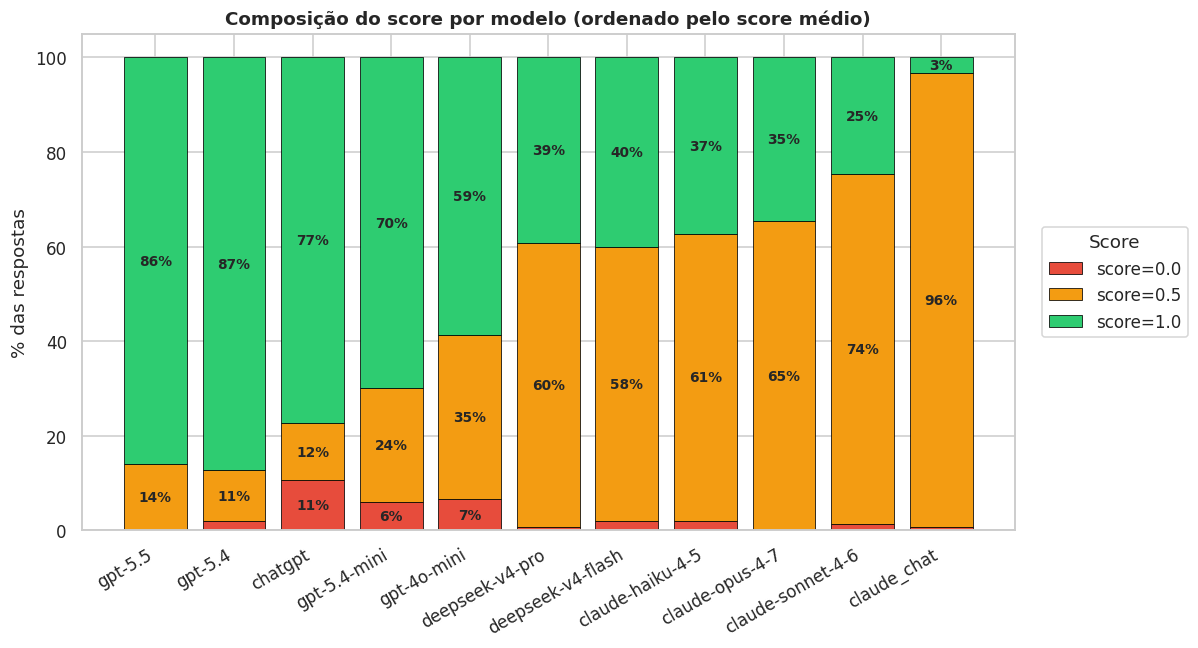

In [4]:
ordem = (df.groupby('modelo')['score'].mean().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(11, 6))
cnt = df.groupby(['modelo','score']).size().unstack(fill_value=0).reindex(ordem)
cnt = cnt[[0.0, 0.5, 1.0]]
cnt_pct = cnt.div(cnt.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(cnt))
for s in [0.0, 0.5, 1.0]:
    ax.bar(cnt.index, cnt_pct[s], bottom=bottom, color=CORES_NOTA[s],
           edgecolor='black', linewidth=0.5, label=f'score={s}')
    for i, (mod, val) in enumerate(cnt_pct[s].items()):
        if val > 3:
            ax.text(i, bottom[i] + val/2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    bottom += cnt_pct[s].values

ax.set_ylabel('% das respostas')
ax.set_title('Composição do score por modelo (ordenado pelo score médio)')
ax.legend(title='Score', loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 3. Tabela mestre: score × tokens por modelo

In [5]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2*n)) / denom
    margem = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (centro - margem, centro + margem)

tab = (df.groupby(['modelo','tipo','provider']).agg(
        score_medio=('score','mean'),
        taxa_perfeita=('score', lambda x: (x==1.0).mean()),
        tokens_media=('n_tokens','mean'),
        tokens_mediana=('n_tokens','median'),
        tokens_p90=('n_tokens', lambda x: x.quantile(0.9)),
        n_total=('score','count'),
).reset_index().sort_values('score_medio', ascending=False))

icw = tab.apply(lambda r: wilson_ci(
    int((df[df['modelo']==r['modelo']]['score']==1.0).sum()),
    int(r['n_total'])), axis=1)
tab['ic_lo'] = [a for a,b in icw]
tab['ic_hi'] = [b for a,b in icw]
tab.round(3)

,modelo,tipo,provider,score_medio,taxa_perfeita,tokens_media,tokens_mediana,tokens_p90,n_total,ic_lo,ic_hi
10,gpt-5.5,api,openai,0.930,0.860,88.933,78.5,162.0,150,0.795,0.907
8,gpt-5.4,api,openai,0.927,0.873,87.413,74.0,168.7,150,0.811,0.917
0,chatgpt,chat,openai,0.833,0.773,51.340,48.0,89.2,150,0.700,0.833
9,gpt-5.4-mini,api,openai,0.820,0.700,80.647,71.5,144.1,150,0.622,0.768
7,gpt-4o-mini,api,openai,0.760,0.587,121.480,111.0,202.5,150,0.507,0.662
6,deepseek-v4-pro,api,deepseek,0.693,0.393,224.100,199.5,381.3,150,0.319,0.473
5,deepseek-v4-flash,api,deepseek,0.690,0.400,192.327,175.0,329.7,150,0.325,0.480
1,claude-haiku-4-5,api,anthropic,0.677,0.373,178.687,166.5,268.1,150,0.300,0.453
2,claude-opus-4-7,api,anthropic,0.673,0.347,197.900,175.5,365.7,150,0.275,0.426
3,claude-sonnet-4-6,api,anthropic,0.617,0.247,238.640,217.0,408.4,150,0.185,0.321


## 4. Scatter: tokens médios × score (cada ponto = um modelo)

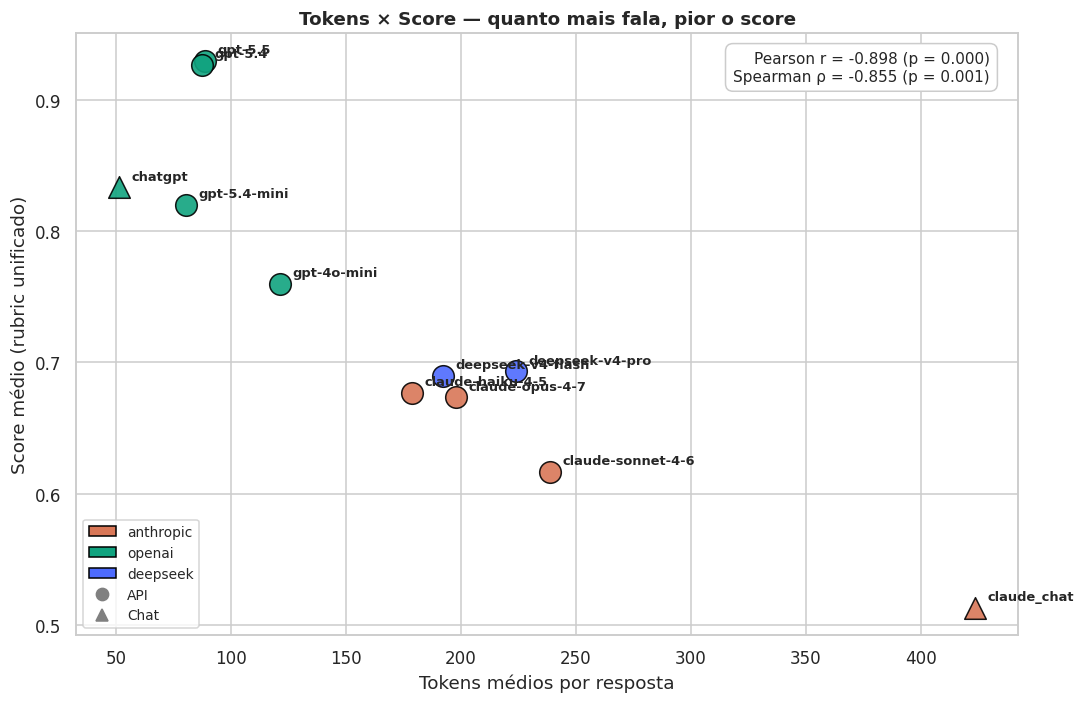


→ Correlação forte e negativa: modelos verbosos pontuam pior.


In [6]:
x = tab['tokens_media'].values
y = tab['score_medio'].values
r_p, p_p = stats.pearsonr(x, y)
r_s, p_s = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(10, 6.5))
cores = [PALETA_PROVEDOR[p] for p in tab['provider']]
markers = ['o' if t=='api' else '^' for t in tab['tipo']]
for xi, yi, c, m, modelo in zip(x, y, cores, markers, tab['modelo']):
    ax.scatter(xi, yi, c=c, s=200, marker=m, edgecolor='black', linewidth=1.0,
               zorder=3, alpha=0.9)
    ax.annotate(modelo, (xi, yi), xytext=(8, 5), textcoords='offset points',
                fontsize=8.5, fontweight='bold')
ax.set_xlabel('Tokens médios por resposta')
ax.set_ylabel('Score médio (rubric unificado)')
ax.set_title('Tokens × Score — quanto mais fala, pior o score')

legend1 = [mpatches.Patch(facecolor=c, edgecolor='black', label=p)
           for p, c in PALETA_PROVEDOR.items()]
legend2 = [plt.Line2D([0],[0], marker='o', color='gray', linestyle='', markersize=8, label='API'),
           plt.Line2D([0],[0], marker='^', color='gray', linestyle='', markersize=8, label='Chat')]
ax.legend(handles=legend1+legend2, loc='lower left', fontsize=9)
ax.text(0.97, 0.97,
        f'Pearson r = {r_p:.3f} (p = {p_p:.3f})\nSpearman ρ = {r_s:.3f} (p = {p_s:.3f})',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#ccc'),
        fontsize=10)
plt.tight_layout(); plt.show()
print(f'\n→ Correlação forte e negativa: modelos verbosos pontuam pior.')

## 5. Boxplot: distribuição de tokens por modelo (escala log)

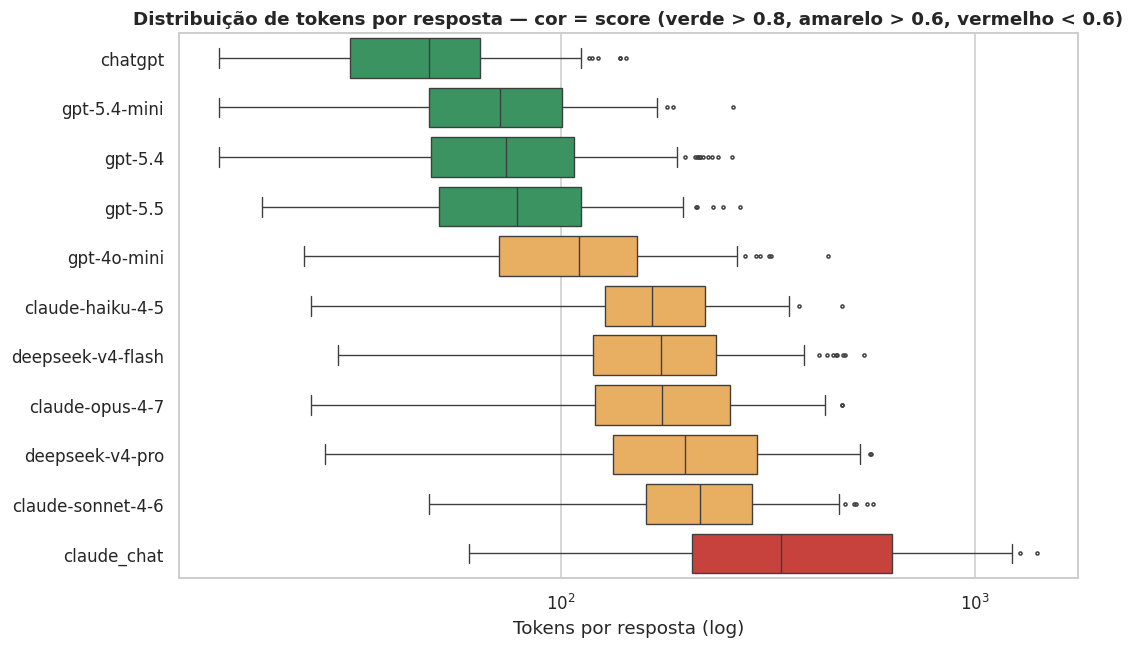

In [7]:
ordem = df.groupby('modelo')['n_tokens'].median().sort_values().index.tolist()
score_por_modelo = df.groupby('modelo')['score'].mean()
cores_box = ['#2ca25f' if score_por_modelo[m] > 0.8
             else '#feb24c' if score_por_modelo[m] > 0.6
             else '#de2d26' for m in ordem]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y='modelo', x='n_tokens', order=ordem,
            hue='modelo', palette=dict(zip(ordem, cores_box)),
            legend=False, fliersize=2, linewidth=0.9, ax=ax)
ax.set_xlabel('Tokens por resposta (log)')
ax.set_ylabel('')
ax.set_xscale('log')
ax.set_title('Distribuição de tokens por resposta — cor = score (verde > 0.8, amarelo > 0.6, vermelho < 0.6)')
plt.tight_layout(); plt.show()

## 6. Focadas vs verbosas: histograma e ECDF

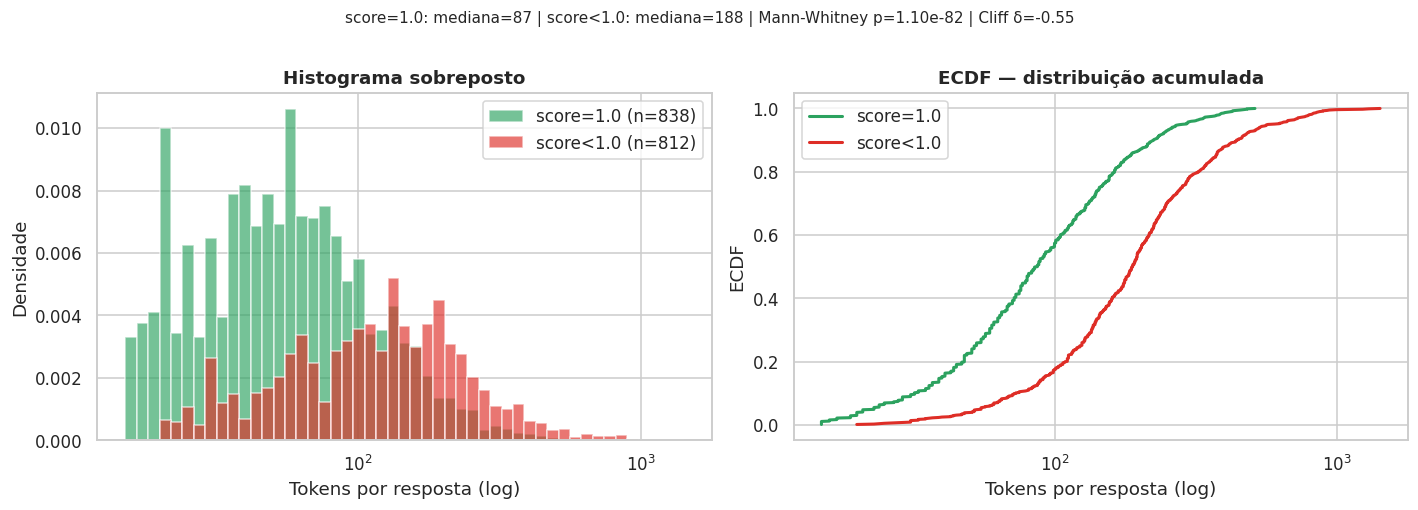


→ Tamanho de efeito (Cliffs δ): grande


In [8]:
def cliffs_delta(a, b):
    from scipy.stats import rankdata
    a = np.asarray(a, float); b = np.asarray(b, float)
    combined = np.concatenate([a, b])
    ranks = rankdata(combined)
    ua = ranks[:len(a)].sum() - len(a)*(len(a)+1)/2
    return 2*ua / (len(a)*len(b)) - 1

# Comparar score=1.0 (focadas/perfeitas) vs score<1.0
tok_alto = df[df.score == 1.0]['n_tokens']
tok_baixo = df[df.score < 1.0]['n_tokens']
u, p = stats.mannwhitneyu(tok_alto, tok_baixo, alternative='less')
d = cliffs_delta(tok_alto.values, tok_baixo.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.logspace(np.log10(max(df.n_tokens.min(),1)), np.log10(df.n_tokens.max()), 50)
axes[0].hist(tok_alto, bins=bins, alpha=0.65, label=f'score=1.0 (n={len(tok_alto)})',
             color='#2ca25f', density=True)
axes[0].hist(tok_baixo, bins=bins, alpha=0.65, label=f'score<1.0 (n={len(tok_baixo)})',
             color='#de2d26', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Tokens por resposta (log)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Histograma sobreposto')
axes[0].legend()

for s, label, color, sub in [(1.0,'score=1.0','#2ca25f', tok_alto),
                              (None,'score<1.0','#de2d26', tok_baixo)]:
    vals = np.sort(sub.values)
    ecdf = np.arange(1, len(vals)+1) / len(vals)
    axes[1].plot(vals, ecdf, label=label, color=color, lw=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Tokens por resposta (log)')
axes[1].set_ylabel('ECDF')
axes[1].set_title('ECDF — distribuição acumulada')
axes[1].legend()

fig.suptitle(
    f'score=1.0: mediana={tok_alto.median():.0f} | score<1.0: mediana={tok_baixo.median():.0f}'
    f' | Mann-Whitney p={p:.2e} | Cliff δ={d:.2f}',
    fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

interp = 'grande' if abs(d) > 0.474 else 'médio' if abs(d) > 0.33 else 'pequeno' if abs(d) > 0.147 else 'desprezível'
print(f'\n→ Tamanho de efeito (Cliffs δ): {interp}')

## 7. Forest plot: taxa de score=1 com IC Wilson 95%

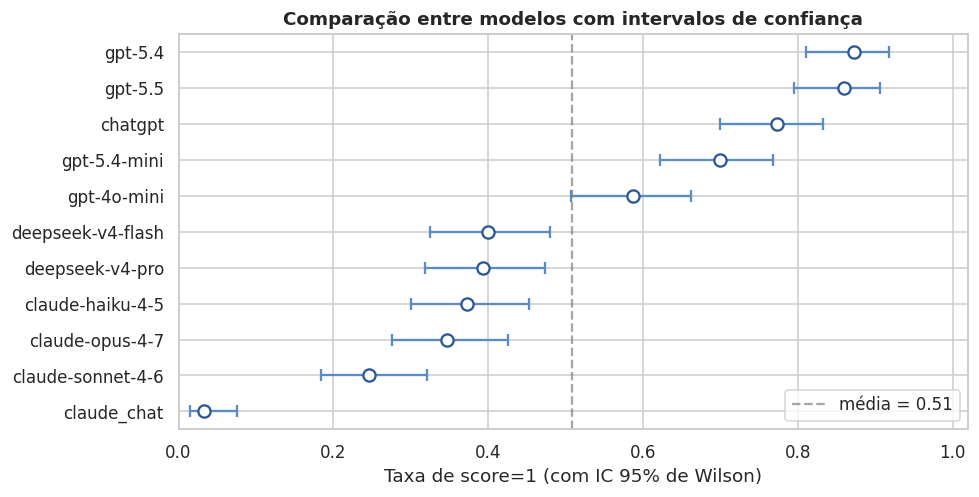

In [9]:
ic_rows = []
for m, grp in df.groupby('modelo'):
    k = int((grp.score == 1.0).sum()); n = len(grp)
    lo, hi = wilson_ci(k, n)
    ic_rows.append({'modelo': m, 'taxa_perfeita': k/n, 'lo': lo, 'hi': hi, 'n': n})
ic_df = pd.DataFrame(ic_rows).sort_values('taxa_perfeita', ascending=True)
media = df['score'].apply(lambda x: 1.0 if x==1.0 else 0).mean()

fig, ax = plt.subplots(figsize=(9, max(4.5, 0.42*len(ic_df))))
ys = np.arange(len(ic_df))
ax.errorbar(ic_df.taxa_perfeita, ys,
            xerr=[ic_df.taxa_perfeita - ic_df.lo, ic_df.hi - ic_df.taxa_perfeita],
            fmt='o', color='#2b5797', ecolor='#5a8bc4', capsize=4, markersize=8,
            markerfacecolor='white', markeredgewidth=1.5)
ax.axvline(media, ls='--', color='gray', alpha=0.7, label=f'média = {media:.2f}')
ax.set_yticks(ys); ax.set_yticklabels(ic_df.modelo)
ax.set_xlabel('Taxa de score=1 (com IC 95% de Wilson)')
ax.set_title('Comparação entre modelos com intervalos de confiança')
ax.set_xlim(0, max(1.0, ic_df.hi.max()) + 0.02)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 8. Por provedor

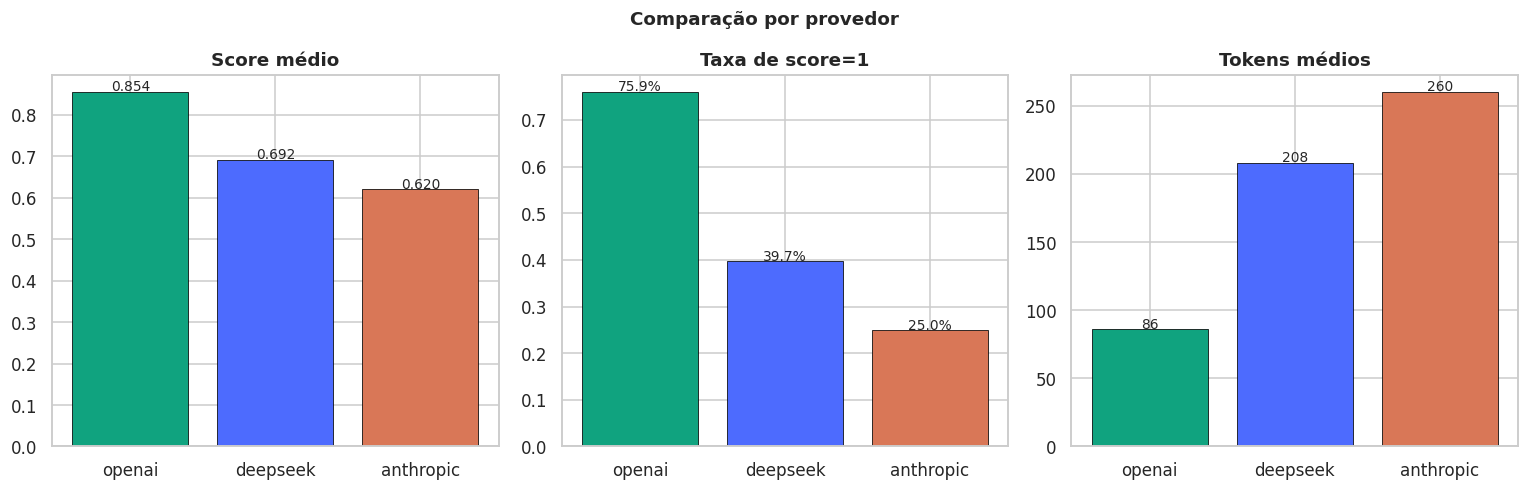

 provider  score_medio  taxa_perfeita  tokens_media   n
   openai        0.854          0.759        85.963 750
 deepseek        0.692          0.397       208.213 300
anthropic        0.620          0.250       259.680 600


In [10]:
prov = (df.groupby('provider').agg(
        score_medio=('score','mean'),
        taxa_perfeita=('score', lambda x: (x==1.0).mean()),
        tokens_media=('n_tokens','mean'),
        n=('score','count'),
).round(3).reset_index().sort_values('score_medio', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col, titulo, fmt in zip(
    axes,
    ['score_medio','taxa_perfeita','tokens_media'],
    ['Score médio','Taxa de score=1','Tokens médios'],
    ['{:.3f}','{:.1%}','{:.0f}']
):
    df_p = prov.sort_values(col, ascending=(col=='tokens_media'))
    cores = [PALETA_PROVEDOR[p] for p in df_p['provider']]
    bars = ax.bar(df_p['provider'], df_p[col], color=cores,
                  edgecolor='black', linewidth=0.5)
    ax.set_title(titulo)
    for i, v in enumerate(df_p[col]):
        ax.text(i, v * 1.005, fmt.format(v), ha='center', fontsize=9)
plt.suptitle('Comparação por provedor', fontweight='bold')
plt.tight_layout(); plt.show()
print(prov.to_string(index=False))

## 9. Resumo

- **Correlação tokens × score** é forte e negativa: modelos verbosos pontuam pior
- **OpenAI** é o provedor mais conciso e melhor pontuado
- **Anthropic** é o mais verboso e pontua pior — mesmo quando a resposta está correta,
  o avaliador penaliza por "enrolar com dados não pedidos"
- O **rubric unificado** captura algo que a avaliação binária de correção pura não
  pega: a qualidade *experimentada* pelo usuário